# Visualizaciones

In [11]:
## Librerias
# Importar librería
from dotenv import load_dotenv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
from transformers import BertModel, BertTokenizer
import gensim.downloader as api
from matplotlib.patches import FancyBboxPatch
# Example code structure for testing the analogy
#from gensim.models import Word2Vec, KeyedVectors


In [12]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env modelos_swmwosge_1008211100
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno modelos_swmwosge_50881200
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_5051100'
pd.set_option('display.max_colwidth', None)

In [19]:
estab_df = pd.read_csv(modelo_dir+'/promedio_interseccion_k.csv')
estab_df["metodo"] = estab_df["metodo"].replace("Procuste", "Procrustes")
estab_df = estab_df.rename(columns={"periodo": "par_periodo"})
estab_df

,par_periodo,metodo,k,promedio interseccion k,desviacion_estandar,ic_inferior,ic_superior
0,"(2009, 2014)",Procrustes,50,0.699886,4.149557e-02,0.002237,0.002335
1,"(2009, 2014)",Procrustes,100,0.754376,2.890919e-02,0.001649,0.001641
2,"(2009, 2014)",Procrustes,150,0.780201,2.157546e-02,0.001203,0.001224
3,"(2009, 2014)",Procrustes,200,0.819024,1.756662e-02,0.000996,0.000976
4,"(2009, 2014)",Procrustes,250,0.840163,1.393822e-02,0.000787,0.000767
...,...,...,...,...,...,...,...
75,"(2014, 2019)",Vecinos,800,0.840000,0.000000e+00,0.000000,0.000000
76,"(2014, 2019)",Vecinos,850,0.790588,1.110676e-16,0.000000,0.000000
77,"(2014, 2019)",Vecinos,900,0.746667,2.221353e-16,NaN,NaN
78,"(2014, 2019)",Vecinos,950,0.707368,1.110676e-16,0.000000,0.000000


In [18]:
import itertools

all_pairs = list(itertools.combinations(range(50), 2))
print(all_pairs)

[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 40), (0, 41), (0, 42), (0, 43), (0, 44), (0, 45), (0, 46), (0, 47), (0, 48), (0, 49), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (1, 26), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 35), (1, 36), (1, 37), (1, 38), (1, 39), (1, 40), (1, 41), (1, 42), (1, 43), (1, 44), (1, 45), (1, 46), (1, 47), (1, 48), (1, 49), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (2, 18), (2, 19

In [21]:
# ABRIR OBJETO
import pickle
with open(modelo_dir+'/top250_periodos_procrustes_df.pkl', 'rb') as file: 
    topn_periodo_procruste = pickle.load(file)

In [27]:
pares_periodo = [ (2009, 2014),(2014, 2019)]
topk = 10
for par_periodo in pares_periodo:
    df =topn_periodo_procruste[par_periodo]
    df = df.rename(columns={"similaridad_semantica_mean": "promedio_similitud_coseno",
                            "similaridad_semantica_confidence_intervals": "intervalo_confianza_95",
                           })
    display(df.head())   

,par_periodo,palabra,promedio_similitud_coseno,intervalo_confianza_95,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
0,"(2009, 2014)",abril,0.671915,"(0.6644882336546588, 0.6793902932233684)","{ocurrido, inundacion, aires, barrio, acaecido, ciudad, autonoma, reparacion}","{junio, ocurrido, ochenta, ciento, inundacion, mes, plazo}","{afectar, desastre, ocurrido, rioja, ciudad, aires, inundacion, barrio, prorrogable, juvenil, acaecido, autonoma, reparacion, plata}","{enero, agropecuario, santa, junio, ocurrido, ochenta, ciento, inundacion, mes, premio, prorrogable, plazo, productivo}"
1,"(2009, 2014)",accesibilidad,0.664728,"(0.6555895507037545, 0.6721097638192658)","{asistido, tecnica, movilidad, trasplantado, discapacitada, reproduccion}","{consentimiento, movilidad, discapacitada}","{piercing, humano, fortalecer, animal, delito, musica, trasplantado, reproduccion, fertilizacion, objetivo, sanguineo, asistido, extension, tecnica, sexual, hereditario, perforacion, tatuaj, terapeutico, movilidad, discapacitada, visceral}","{concurrencia, automatico, hemocomponent, rehabilitacion, espacio, trasplantado, dato, cuyo, prepagar, seguridad, fertilizacion, fondo, poblacion, area, presupuesto, asistido, equinoterapia, maternidad, consentimiento, hijo, garantizar, actualizacion, informado, judicial, permanente, desfibrilador, movilidad, discapacitada}"
2,"(2009, 2014)",acceso,0.660621,"(0.6486434642897696, 0.6703580587771945)","{formulacion, beber, agregar, lugar, comercialicir}","{formulacion, solar, consumar, potable, comercialicir}","{formulacion, espacio, ensenanza, reproduccion, comida, fertilizacion, relevamiento, agregar, medida, excesivo, asistido, sal, consumar, epidemiologico, comercialicir, curso, pre, auxilio, beber, lugar}","{concurrencia, muerte_subita, formulacion, solar, espacio, potable, exhibicion, agua, area, padecer, biomedico, medida, asistido, sal, consumar, epidemiologico, garantizar, comercialicir, vacunacion, radiacion, gasificado, publico, relacionado, deber}"
3,"(2009, 2014)",accidente,0.680180,"(0.6740585597473483, 0.6871100170572716)","{seguimiento, cerebrovascular, acv, presupuesto, peligroso, acvo, sustancia, dano}","{caso, cerebrovascular, acv, acvo, vascular}","{sufrir, seguimiento, dano, cerebrovascular, acv, presupuesto, peligroso, llamado, acvo, represa, sustancia, consecuencia}","{juegos, rehabilitacion, vino, natural, caso, mancha, seguimiento, digno, cerebrovascular, presupuesto, acvo, sustancia, vascular, llamado, vida, oporto, adquirido, artriti, acv, reumatoidea}"
4,"(2009, 2014)",acompanante,0.390003,"(0.37864420341190097, 0.4012885634873209)","{parto, proceso, embarazo, permanencia, gratuidad, nacimiento}","{piercing, recurso, cosmiatrio, terapeutico, obstetricia, equinoterapia, cosmetologia}","{parto, embarazo, privado, permanencia, inciso, suspension, nacimiento, proceso, percibir, prenatal, violencia, marco, reconstruccion, maternidad, mujer, consultoria, embarazado, partos, gratuidad, situacion, puerperio}","{perforacion, piercing, tatuaj, recurso, cosmiatrio, terapeutico, ejercicio, tecnico, obstetricia, equinoterapia, cosmetologia}"


,par_periodo,palabra,promedio_similitud_coseno,intervalo_confianza_95,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
0,"(2014, 2019)",accesibilidad,0.246599,"(0.22559860755138836, 0.2647665261127905)","{consentimiento, movilidad, discapacitada}","{elemento, gestion}","{politica, concurrencia, automatico, hemocomponent, proteccion, rehabilitacion, espacio, trasplantado, dato, cuyo, prepagar, seguridad, fertilizacion, fondo, poblacion, area, presupuesto, asistido, equinoterapia, maternidad, consentimiento, hijo, garantizar, actualizacion, informado, judicial, permanente, desfibrilador, movilidad, discapacitada}","{producto, incorporar, ame, espacio, habilitado, atrofia, dato, celiaca, muscular, exhibicion, tecnologico, examen, fumar, gestion, congenita, digno, poblacion, elemento, calendario, espinal, numerir, licenciado, paliativo, similar, gratuito, etiqueta, ambiental, gluten, oftalmologico, trabajo, tabaco, visual, condicion, elaborado}"
1,"(2014, 2019)",acceso,0.575210,"(0.5596438988046418, 0.5901890391455907)","{formulacion, solar, consumar, potable, comercialicir}","{potable, agua}","{piercing, concurrencia, muerte_subita, formulacion, solar, espacio, potable, exhibicion, agua, area, padecer, investigacion, produccion, biomedico, medida, asistido, sal, consumar, regulacion, epidemiologico, garantizar, comercialicir, vacunacion, radiacion, gasificado, deber, publico, relacionado, lugar}","{edad, privado, proteccion, vacuna, calidad, potable, punto, cuyo, medicamento, reproduccion, agua, apto, proteina, padecer, presupuesto, farmacia, necesario, leche, declarar, dependencia, garantizar, aplv, acv, gratuidad, provision, universal, fiebre, minimo, departamento, prioritario}"
2,"(2014, 2019)",accidente,0.581097,"(0.566722604893749, 0.593561207398835)","{vascular, acvo, cerebrovascular, acv}","{cerebrovascular, acv, alergia, proteina, alzheimer}","{juegos, rehabilitacion, vino, natural, caso, recurso, mancha, seguimiento, digno, cerebrovascular, presupuesto, acvo, sustancia, vascular, exposicion, sida, llamado, vida, oporto, adquirido, artriti, radiacion, promover, acv, transcurso, minimo, reumatoidea}","{politica, regional, cumplimiento, enfermo, alzheimer, vino, atrofia, hepatitis, deteccion, mancha, prevencion, anual, cerebrovascular, proteina, calendario, espinal, vascular, leche, violencia, leyenda, quimico, exigencia, alergia, psicologico, prevenibl, llamado, oporto, publicitario, artriti, campana, aplv, radiacion, cirugia, acv, evaluacion, malformacion, fiebre}"
3,"(2014, 2019)",acompanante,0.671973,"(0.6657487262565724, 0.6781688067939733)","{piercing, recurso, cosmiatrio, terapeutico, ejercicio, obstetricia, equinoterapia, cosmetologia}","{informado, articulo, inciso, obstetricia, consentimiento, estetico}","{perforacion, piercing, tatuaj, recurso, cosmiatrio, terapeutico, ejercicio, tecnico, obstetricia, equinoterapia, cosmetologia}","{receta, informado, profesional, terapeutico, articulo, ejercicio, inciso, obstetricia, tecnico, primario, sustitucion, psicologico, consentimiento, licenciado, victima, estetico}"
4,"(2014, 2019)",actividad,0.610641,"(0.5940920575312633, 0.6239991903268857)","{acompanante, equinoterapia}","{tecnico, obstetricia, odontologia}","{piercing, juegos, animal, tecnico, consejo, ensenanza, deportivo, cosmetologia, jubilacion, recurso, azar, conexa, ejercicio, lavado, asistido, obstetricia, equinoterapia, activo, acompanante, estetico, perforacion, tatuaj, pension, cosmiatrio, terapeutico, impuesto, fisico, evaluacion, explotacion}","{animal, rehabilitacion, tecnico, ter, medicina, ejercicio, domiciliario, odontologia, cualquiera, licenciado, digital, asistido, receta, marco, fetal, reconocimiento, obstetricia, equinoterapia, funcion, profesion, estetico, complementario, financiero, terapeutico, fisico, gratuidad}"


In [28]:
# ABRIR OBJETO
with open(modelo_dir+'/top250_periodos_NN_df.pkl', 'rb') as file: 
    topn_periodo_NN = pickle.load(file)

In [29]:
topn_periodo_NN

{(2009,
  2014):       par_periodo        palabra  similaridad_semantica_mean  \
 0    (2009, 2014)  accesibilidad                   -4.780488   
 1    (2009, 2014)      accidente                   -5.586957   
 2    (2009, 2014)    acompanante                   -0.040000   
 3    (2009, 2014)      actividad                   -5.742857   
 4    (2009, 2014)         activo                   -4.555556   
 ..            ...            ...                         ...   
 325  (2009, 2014)      violencia                   -2.900000   
 326  (2009, 2014)          virus                   -2.940000   
 327  (2009, 2014)         visual                   -2.880000   
 328  (2009, 2014)          vital                   -4.340000   
 329  (2009, 2014)     voluntario                   -5.866667   
 
                                similaridad_ci  \
 0    (-5.048780487804878, -4.439024390243903)   
 1    (-5.782608695652174, -5.434782608695652)   
 2                 (-0.13602235003367033, 0.0)   
 3

In [30]:
for par_periodo in pares_periodo:
    df = topn_periodo_NN[par_periodo]
    df = df.rename(columns={"similaridad_semantica_mean": "promedio_puntaje_de_cambio",
                            "similaridad_semantica_confidence_intervals": "intervalo_confianza_95",
                           })
    display(df.head())  

,par_periodo,palabra,promedio_puntaje_de_cambio,similaridad_ci,vt1,vt2,vt1_union,vt2_union
0,"(2009, 2014)",accesibilidad,-4.780488,"(-5.048780487804878, -4.439024390243903)","{asistido, fondo, humano, tecnica, efecto, sexual, integral, persona, reproduccion}","{poblacion, automatico, espacio, hijo, garantizar, prepagar}","{virus, humano, automatico, proteccion, rehabilitacion, espacio, accidente, adolescente, celiaca, consumo, victima, prepagar, hepatitis, reproduccion, publicidad, anos, fondo, poblacion, sexo, padecer, rotulo, efecto, regimen, responsable, terapia, asistido, leche, tecnica, regulacion, nacido, sexual, sistema, campana, historia, promover, inundacion, perjudicial, beneficio, dengue, integral, discapacidad, persona, clinico}","{politica, seguro, automatico, proteccion, acceso, rehabilitacion, espacio, adolescente, potable, encontrar, cuyo, prepagar, seguridad, reproduccion, medicina, fondo, codigo, poblacion, terapia, asistido, beneficiario, hijo, garantizar, obra, administracion, vacunacion, asignacion, historia, beneficio, desfibrilador, publico, universal, ingreso, persona, donante}"
1,"(2009, 2014)",accidente,-5.586957,"(-5.782608695652174, -5.434782608695652)","{seguimiento, promover, rehabilitacion, minimo, sustancia, consecuencia}","{seguimiento, rehabilitacion, vida, minimo, responsable, sustancia}","{santa, rio, rehabilitacion, espacio, prorrogable, mental, capacitacion, victima, cuyo, hepatitis, exhibicion, reproduccion, volcan, asistencia, provincia, seguimiento, prevencion, diabetico, desastre, ochenta, padecer, tratamiento, minimo, denominado, sustancia, productivo, concientizacion, asistido, leyenda, atencion, gluten, sexual, campana, promover, inundacion, perjudicial, dengue, plazo, ingreso, trastorno, movil, neuquen, consecuencia}","{virus, diabetes, mes, rehabilitacion, victima, exhibicion, octubre, prevencion, seguimiento, cualquiera, minimo, responsable, sustancia, distribucion, concientizacion, junio, prohibir, vida, paciente, campana, tabaco, promover, lucha, dengue, elaborado}"
2,"(2009, 2014)",acompanante,-0.040000,"(-0.13602235003367033, 0.0)","{privado, embarazado, nacido, inciso, situacion, vida, mujer, hijo, recien}","{asistido, profesional, ejercicio, regulacion, actividad, reproduccion}","{seguro, automatico, privado, modificacion, espacio, inciso, deportivo, adolescente, victima, anos, azar, familiar, institucion, derecho, ciudadano, nino, nacido, externo, prohibir, vida, hijo, recien, garantizar, implementar, mujer, vacunacion, asignacion, historia, embarazado, perjudicial, nina, desfibrilador, situacion, universal, escolar, clinico}","{profesional, rehabilitacion, obligacion, deportivo, reproduccion, medicina, volcan, azar, juego, ejercicio, droga, terapia, especialidad, asistido, nutricion, tecnica, regulacion, impuesto, medicinal, actividad}"
3,"(2009, 2014)",actividad,-5.742857,"(-6.0, -5.485714285714286)","{medicina, asistencial, santa, azar, juego, ejercicio, plazo, deportivo, adolescente, consecuencia, economico, productivo}","{azar, juego, ejercicio, impuesto, evaluacion, deportivo}","{asistencial, santa, estudio, profesional, diabetes, ciento, modificacion, mes, articulo, rehabilitacion, inciso, prorrogable, deportivo, adolescente, termino, prepagar, medicina, volcan, azar, ochenta, juego, ejercicio, droga, farmacia, ingreso, terapia, distribucion, productivo, localidad, junio, regulacion, zona, afectado, prohibicion, hijo, complementario, nina, impuesto, emergencia, plazo, inter, discapacidad, consecuencia, economico}","{profesional, diabetes, decreto, privado, modificacion, rehabilitacion, espacio, obligacion, deportivo, cuyo, reproduccion, azar, institucion, centro, apto, juego, ejercicio, tipo, terapia, asistido, regulacion, externo, practica, tabaco, complementario, beneficio, impuesto, evaluacion, publico, emergencia, elaborado, consecuencia}"
4,"(2009, 2014)",activo,-4.555556,"(-4.849495348384333, -4.224086500804838)","{azar, complementario, contener, juego, activ

,par_periodo,palabra,promedio_puntaje_de_cambio,similaridad_ci,vt1,vt2,vt1_union,vt2_union
0,"(2014, 2019)",academia,-0.240000,"(-0.38, -0.14)","{institucion, centro, desfibrilador, externo, deportivo, preventivo}","{cordoba, decreto, medica}","{gastronomico, educativo, automatico, privado, equipo, espacio, deportivo, establecimiento, preventivo, potable, reproduccion, institucion, centro, apto, oncologico, personal, obligatoriedad, externo, equinoterapia, certificado, practica, desfibrilador, evaluacion, actividad, provision}","{diabetes, decreto, articulo, vih, misoprostol, instituir, tdah, reproduccion, hiperactividad, ejercicio, licenciado, educacion, semana, especialidad, receta, derivado, zona, equinoterapia, epidemiologico, medica, cordoba, tabaco, medicinal, visual, inclusion, marzo, derogacion, elaborado, clinico, infeccion}"
1,"(2014, 2019)",accesibilidad,-0.660000,"(-0.88, -0.48)","{espacio, equinoterapia, prepagar}",{gratuito},"{seguro, automatico, proteccion, acceso, rehabilitacion, espacio, adolescente, potable, encontrar, prepagar, seguridad, reproduccion, medicina, fondo, codigo, grupo, terapia, asistido, marco, braille, prevenibl, equinoterapia, obra, garantizar, administracion, vacunacion, asignacion, endometriosis, historia, terapeutico, beneficio, desfibrilador, relacion, publico, integral, universal, ingreso, persona, donante}","{producto, virus, estudio, incorporar, rehabilitacion, espacio, comercializacion, potable, preventivo, hepatitis, agua, centro, argentino, banco, licenciado, neonatal, gratuito, braille, respuesta, pesquisa, celiaco, prevenibl, equinoterapia, externo, recien, envase, alimenticio, certificado, practica, patologia, tabaco, historia, embarazado, instalacion, desfibrilador, visual, provision, condicion, libre, elaborado, menor, donante}"
2,"(2014, 2019)",accidente,-3.860465,"(-4.093023255813954, -3.627906976744186)","{monoxido, rehabilitacion, vida, responsable, sustancia, carbono}","{campana, carbono, alergia, monoxido}","{diabetes, fibromialgia, mes, vih, rehabilitacion, preventivo, victima, riesgo, prevencion, sindrome, oncologico, alto, cualquiera, responsable, sustancia, semana, distribucion, concientizacion, derivado, prevenibl, vida, paciente, publicitario, campana, tabaco, promover, monoxido, lucha, dengue, utilizacion, elaborado, carbono}","{termino, victima, regulatorio, implementacion, hepatitis, control, deteccion, prevencion, anual, sindrome, oncologico, tratamiento, plan, semana, leche, argentina, violencia, trombofilia, ciudadano, diagnostico, alergia, pesquisa, difusion, nacido, prevenibl, programa, vida, epidemiologico, mujer, publicitario, vacunacion, campana, endometriosis, cronico, embarazado, monoxido, evaluacion, marzo, fibromialgia, infantil, carbono}"
3,"(2014, 2019)",acompanant,-3.739130,"(-3.9782608695652173, -3.4782608695652173)","{edad, terapeutico, beneficio, ejercicio, equinoterapia}","{desarrollo, terapeutico}","{edad, proteccion, vih, rehabilitacion, adolescente, tdah, encontrar, reproduccion, medicina, hiperactividad, ejercicio, deficit, asistido, receta, regulacion, equinoterapia, expendio, terapeutico, beneficio, nina, actividad, fibromialgia, menor, persona}","{profesional, diabetes, promocion, seguro, hospital, rehabilitacion, tdah, especial, victima, precio, hiperactividad, registro, ejercicio, cualquiera, deficit, regimen, cuidado, desarrollo, licenciado, educacion, terapia, asistido, clinica, trombofilia, braille, respuesta, regulacion, equinoterapia, vida, sistema, certificado, patologia, ministerio, endometriosis, unico, terapeutico, actividad, derogacion, economico}"
4,"(2014, 2019)",actividad,-5.000000,"(-5, -5)","{profesional, terapeutico, ejercicio, regulacion, evaluacion, equinoterapia, deportivo, preventivo, terapia}","{receta, marco, complementario, terapeutico, ejercicio, rehabilitacion, equinoterapia, cualquiera, licenciado}","{profesional, decreto, privado, modificacion, rehabilitacion, espacio, deportivo, preventivo, reproduccion, ce

In [8]:
# Load a pre-trained model
#wv = KeyedVectors.load_word2vec_format("glove-wiki-gigaword-100") #KeyedVectors.load_word2vec_format('path/to/your/model.bin', binary=True)

# Or load a model using the Gensim downloader API
import gensim.downloader as api
model = api.load (glove-wiki-gigaword-100)  #('word2vec-google-news-300')

NameError: name 'glove' is not defined

In [2]:
# Perform the vector operation
result = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
print(result)  # This should output [('queen', similarity_score)]

MemoryError: Unable to allocate 3.35 GiB for an array with shape (3000000, 300) and data type float32

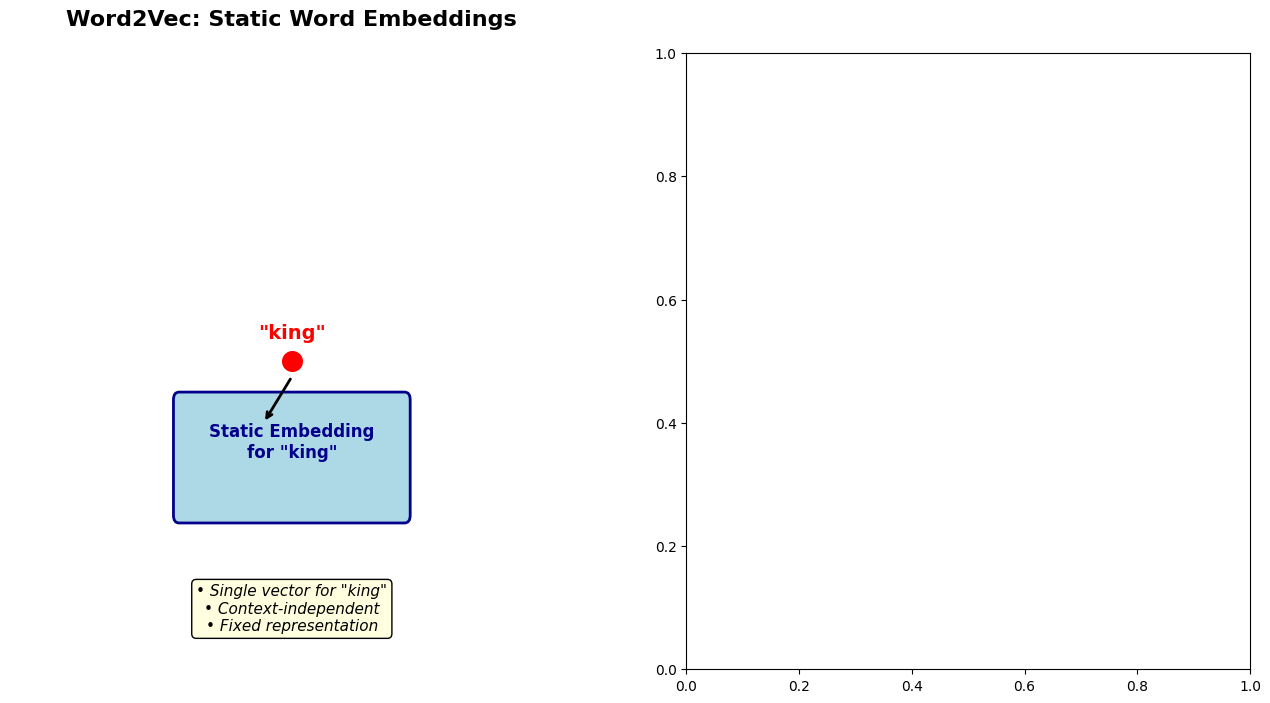

In [2]:
# Configuración de estilo para mejores visualizaciones
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# =============================================================================
# 1. VISUALIZACIÓN WORD2VEC (EMBEDDINGS ESTÁTICOS)
# =============================================================================

ax1.set_title('Word2Vec: Static Word Embeddings', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)

# Punto único para "king" en Word2Vec
king_point = [5, 4]
ax1.scatter(king_point[0], king_point[1], color='red', s=200, zorder=5)
ax1.text(king_point[0], king_point[1] + 0.3, '"king"', fontsize=14, 
         fontweight='bold', ha='center', color='red')

# Caja representando el embedding estático
embedding_box = FancyBboxPatch((3, 2), 4, 1.5, boxstyle="round,pad=0.1",
                              facecolor='lightblue', edgecolor='darkblue', linewidth=2)
ax1.add_patch(embedding_box)
ax1.text(5, 2.75, 'Static Embedding\nfor "king"', fontsize=12, ha='center', 
         fontweight='bold', color='darkblue')

# Flecha conectando la palabra al embedding
ax1.annotate('', xy=(4.5, 3.2), xytext=(5, 3.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax1.text(5, 0.5, '• Single vector for "king"\n• Context-independent\n• Fixed representation', 
         fontsize=11, ha='center', style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

ax1.set_xticks([])
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)

In [3]:
# =============================================================================
# 2. VISUALIZACIÓN BERT (EMBEDDINGS CONTEXTUALES)
# =============================================================================

ax2.set_title('BERT: Contextual Word Embeddings', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)

# Dos puntos diferentes para "king" en diferentes contextos
king_context1 = [3, 6]
king_context2 = [7, 6]

ax2.scatter(king_context1[0], king_context1[1], color='red', s=200, zorder=5)
ax2.scatter(king_context2[0], king_context2[1], color='red', s=200, zorder=5)

# Texto de las oraciones
ax2.text(3, 6.8, '"The king of Spain"', fontsize=10, ha='center', 
         bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen"))
ax2.text(7, 6.8, '"The lion is\nthe king of the jungle"', fontsize=10, ha='center',
         bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen"))

# Dos cajas diferentes para embeddings contextuales
embedding_box1 = FancyBboxPatch((1.5, 2), 3, 1.5, boxstyle="round,pad=0.1",
                               facecolor='lightcoral', edgecolor='darkred', linewidth=2)
embedding_box2 = FancyBboxPatch((5.5, 2), 3, 1.5, boxstyle="round,pad=0.1",
                               facecolor='lightcoral', edgecolor='darkred', linewidth=2)

ax2.add_patch(embedding_box1)
ax2.add_patch(embedding_box2)

ax2.text(3, 2.75, 'Contextual\nEmbedding 1', fontsize=11, ha='center', 
         fontweight='bold', color='darkred')
ax2.text(7, 2.75, 'Contextual\nEmbedding 2', fontsize=11, ha='center', 
         fontweight='bold', color='darkred')

# Flechas conectando los contextos a sus embeddings
ax2.annotate('', xy=(2.5, 3.2), xytext=(3, 5.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='darkred'))
ax2.annotate('', xy=(6.5, 3.2), xytext=(7, 5.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='darkred'))

ax2.text(5, 0.5, '• Different vectors for "king"\n• Context-dependent\n• Dynamic representation', 
         fontsize=11, ha='center', style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

ax2.set_xticks([])
ax2.set_yticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [ ]:

# =============================================================================
# 3. DEMOSTRACIÓN PRÁCTICA CON MODELOS REALES (OPCIONAL)
# =============================================================================

print("=" * 70)
print("DEMONSTRATION WITH REAL MODELS")
print("=" * 70)

# Cargar Word2Vec pre-entrenado
print("\n1. Loading Word2Vec model...")
try:
    word2vec_model = api.load('word2vec-google-news-300')
    king_vector_w2v = word2vec_model['king']
    print(f"✓ Word2Vec: Vector for 'king' shape: {king_vector_w2v.shape}")
    print(f"  Single static vector across all contexts")
except:
    print("✗ Word2Vec model not available, but concept remains valid")

# Cargar BERT y demostrar embeddings contextuales
print("\n2. Loading BERT model for contextual embeddings...")
try:
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased')
    
    # Dos oraciones diferentes con la palabra "king"
    sentences = [
        "The king of Spain gave a speech",
        "The lion is the king of the jungle"
    ]
    
    print(f"✓ BERT model loaded successfully")
    print(f"  Analyzing 2 different contexts for 'king':")
    
    for i, sentence in enumerate(sentences):
        inputs = tokenizer(sentence, return_tensors='pt', padding=True, truncation=True)
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Obtener los embeddings de la última capa
        embeddings = outputs.last_hidden_state
        
        # Encontrar la posición de "king" en los tokens
        tokens = tokenizer.tokenize(sentence)
        king_index = tokens.index('king') if 'king' in tokens else -1
        
        if king_index != -1:
            king_embedding = embeddings[0, king_index + 1, :]  # +1 por el token [CLS]
            print(f"  Context {i+1}: '{sentence}'")
            print(f"    Embedding shape: {king_embedding.shape}")
            print(f"    First 5 values: {king_embedding[:5].numpy()}")
            print()
            
except Exception as e:
    print(f"✗ BERT demonstration failed: {e}")
    print("  But the conceptual difference is clearly shown in the visualization")

print("=" * 70)
print("KEY TAKEAWAYS:")
print("• Word2Vec: One word → One vector (static)")
print("• BERT: One word → Multiple vectors (contextual)")
print("• Context matters for nuanced semantic understanding")
print("=" * 70)

DEMONSTRATION WITH REAL MODELS

1. Loading Word2Vec model...
[=====---------------------------------------------] 10.7% 178.2/1662.8MB downloaded